# Прогнозирование поведения клиента (ДЗ)

Привет!

В этом домашнем задании тебе предстоит построить кривые def rate, внедрить def rate в NPV-модель и исследовать зависимость обновленной модели от выбранного скора (подробные пункты перечислены ниже).

Для выполнения тебе понадобится выборка с данными, которую использовали на семинаре (**data_vintages.csv**), x_score и PD (**data_scores.csv**). Не бойся выходить за рамки методов, предлженных в лекции.

Главное - не забывай **аргументировать** свой выбор и давать **комментарии** своим действиям. 

Удачи!

#### Как будет оцениваться работа:
За это ДЗ ты можешь получить максимум **10 баллов**. Все пункты весят по-разному, баллы указаны рядом с пунктами. Баллы могут сниматься в случае неполного выполнения задания или отсутствия аргументации.


#### Задачи:

1) Построить кривые DEF rate (5 баллов)
    - Выбрать переменную для разбивки по бакетам (0.5 балла)
    - Провести анализ поколений (0.5 балла)
    - Построить винтажи DEF rate (0.5 балла)
    - Провести анализ на особые точки (0.5 балла)
    - Провести анализ наличия внешних воздействий и при необходимости вычистить кривые (2 балла)
    - Построить среднее по винтажам для каждого бакета (0.5 балла)
    - Сгладить кривые (0.5 балла)
    
2) Внести в модель построенную кривую DEF rate и исследовать зависимость от скора (5 баллов)
    - Реализовать метод для расчета DEF rate по поданному скору (3 балла)
    - Рассчитать NPV для кредита с заданными параметрами (1 балл)
    - Построить кривую зависимости NPV от скора (1 балл)
    
**Пожалйуста, аргументируйте свои решения по каждому пункту**

В качестве результата приложи текущий ноутбук с названием 'Surname_def.ipynb'

## Кривые DEF rate

#### Выгружаем данные с винтажами

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams["figure.figsize"] = (12, 6)

df = pd.read_csv(
    "data_vintages.csv",
    sep=";",
    encoding="cp1251",
    index_col=0,
    parse_dates=["gen_month_dt", "gen_quarter_dt"],
)
print(df.shape)
df.head()

(2493268, 12)


,user_id,statement_num,gen_month_dt,gen_quarter_dt,clo_flg,def_flg,dlq_flg,act_flg,prev_clo_flg,prev_def_flg,prev_dlq_flg,prev_act_flg
0,127336,19,2019-07-01,2019-07-01,0,0,0,1,0,0,0,1
1,35907,16,2019-04-01,2019-04-01,1,0,0,0,1,0,0,0
2,45228,21,2019-05-01,2019-04-01,0,0,0,1,0,0,0,1
3,39035,23,2019-07-01,2019-07-01,0,0,0,1,0,0,0,1
4,130780,19,2019-08-01,2019-07-01,1,0,0,0,1,0,0,0


#### Выгружаем данные со скорами для дальнейшей разбивки на бакеты

In [3]:
df_scores = pd.read_csv(
    "data_scores.csv", sep=";", encoding="cp1251", decimal=",", index_col=0
)
print(df_scores.shape)
df_scores.describe()

(104820, 3)


,user_id,pd,x_score
count,104820.000000,104820.000000,104820.000000
mean,109218.959359,0.037311,0.244520
std,62808.499700,0.025654,0.116533
min,2.000000,0.000252,0.039711
25%,54952.500000,0.015750,0.157428
50%,109257.500000,0.032285,0.218915
75%,163110.250000,0.055092,0.308420
max,222273.000000,0.099997,0.793186


#### Бъем выборку на бакеты и джойним с данными с винтажами

In [4]:
buckets = 3


def add_buckets(scores, col, name, n_buckets=buckets):
    scores = scores.sort_values([col], ignore_index=True)
    scores[name] = np.minimum(scores.index // (scores.shape[0] // n_buckets), n_buckets - 1)
    return scores


df_scores = add_buckets(df_scores, "pd", "pd_bucket")
df_scores = add_buckets(df_scores, "x_score", "x_bucket")

print(df_scores.groupby("pd_bucket")["pd"].agg(["min", "max", "mean", "count"]))
print(df_scores.groupby("x_bucket")["x_score"].agg(["min", "max", "mean", "count"]))

df = df.merge(
    df_scores[["user_id", "pd", "x_score", "pd_bucket", "x_bucket"]],
    how="left",
    on="user_id",
).dropna()

df.head()

                min       max      mean  count
pd_bucket                                     
0          0.000252  0.020798  0.011040  34940
1          0.020798  0.046316  0.032685  34940
2          0.046317  0.099997  0.068209  34940
               min       max      mean  count
x_bucket                                     
0         0.039711  0.176967  0.133270  34940
1         0.176968  0.272747  0.220838  34940
2         0.272748  0.793186  0.379452  34940


,user_id,statement_num,gen_month_dt,gen_quarter_dt,clo_flg,def_flg,dlq_flg,act_flg,prev_clo_flg,prev_def_flg,prev_dlq_flg,prev_act_flg,pd,x_score,pd_bucket,x_bucket
0,127336,19,2019-07-01,2019-07-01,0,0,0,1,0,0,0,1,0.021296,0.469410,1,2
1,35907,16,2019-04-01,2019-04-01,1,0,0,0,1,0,0,0,0.064742,0.157215,2,0
2,45228,21,2019-05-01,2019-04-01,0,0,0,1,0,0,0,1,0.018490,0.469583,0,2
3,39035,23,2019-07-01,2019-07-01,0,0,0,1,0,0,0,1,0.025882,0.210896,1,1
4,130780,19,2019-08-01,2019-07-01,1,0,0,0,1,0,0,0,0.024330,0.269492,1,1


### Выбери переменную, которая делит кривые наилучшим образом (0.5 баллов)

 Из двух скоров (x_score и ваш PD) выбери тот, который разделяет кривые наилучшим образом

In [5]:
def def_rate_agg(data, keys):
    agg = (
        data.groupby(keys, as_index=False)
        .agg(
            def_cnt=("def_flg", "sum"),
            prev_def_cnt=("prev_def_flg", "sum"),
            prev_act_cnt=("prev_act_flg", "sum"),
            cnt=("user_id", "count"),
        )
    )
    agg["new_def_cnt"] = agg["def_cnt"] - agg["prev_def_cnt"]
    agg["def_rate"] = agg["new_def_cnt"] / agg["prev_act_cnt"]
    return agg

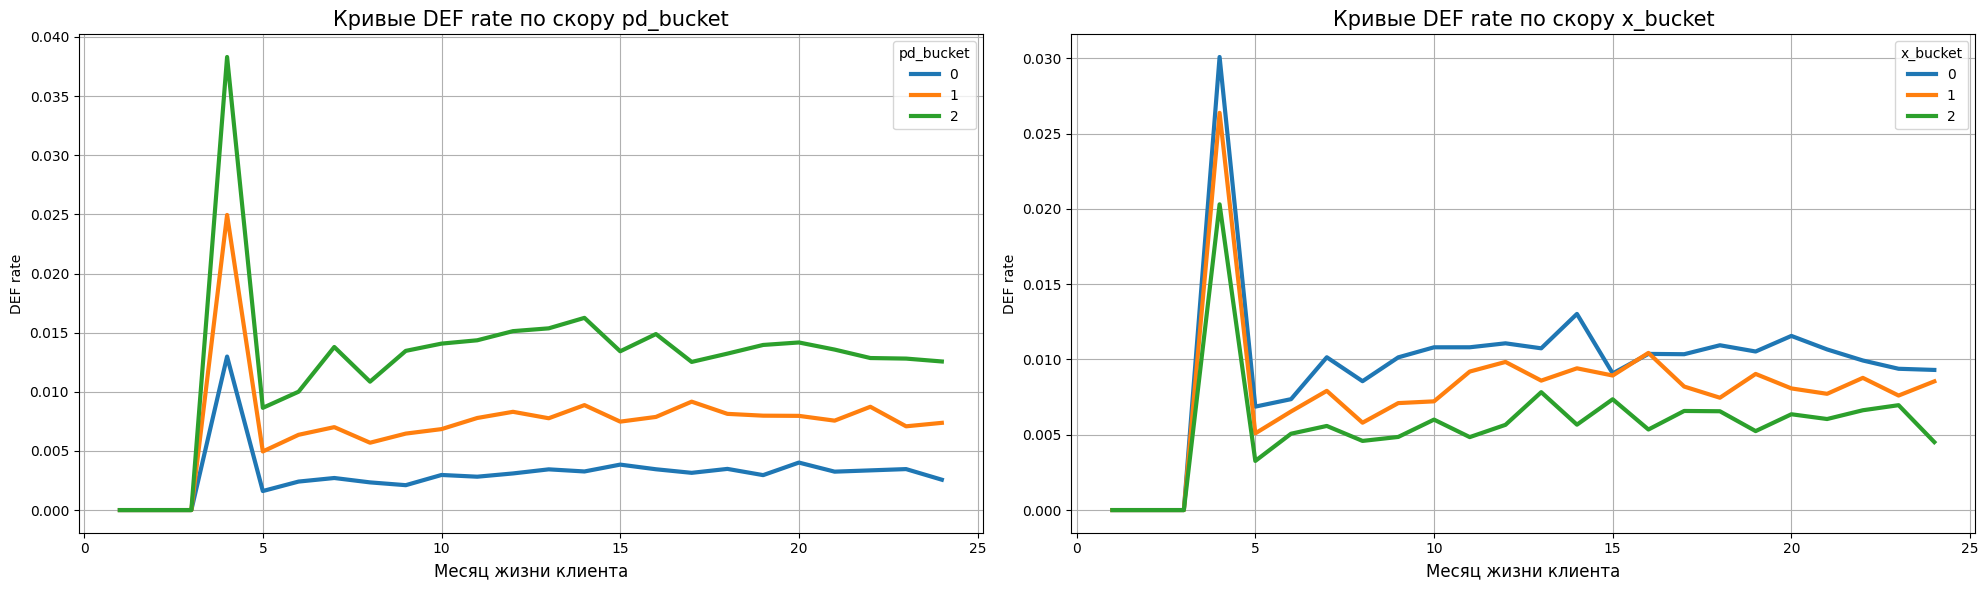

,PD,X score
"Нижний бакет, %",0.30,0.57
"Верхний бакет, %",1.33,1.01
Отношение max и min,4.41,1.75
Средний относительный разброс,1.30,0.55


In [6]:
def plot_def_rate_by_bucket(data, bucket, ax=None):
    curves = (
        def_rate_agg(data, [bucket, "statement_num"])
        .pivot(index="statement_num", columns=bucket, values="def_rate")
    )
    ax = curves.plot(ax=ax, grid=True, lw=3)
    ax.set_title("Кривые DEF rate по скору " + bucket, size=15)
    ax.set_xlabel("Месяц жизни клиента", size=12)
    ax.set_ylabel("DEF rate")
    return curves

def separation_metrics(curves, start=5):
    tail = curves.loc[start:]
    means = tail.mean()
    return pd.Series({
        "Нижний бакет, %": means.min() * 100,
        "Верхний бакет, %": means.max() * 100,
        "Отношение max и min": means.max() / means.min(),
        "Средний относительный разброс": ((tail.max(axis=1) - tail.min(axis=1)) / tail.mean(axis=1)).mean(),
    })

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
curves_pd = plot_def_rate_by_bucket(df, "pd_bucket", axes[0])
curves_x = plot_def_rate_by_bucket(df, "x_bucket", axes[1])
plt.tight_layout()
plt.show()

pd.DataFrame({"PD": separation_metrics(curves_pd), "X score": separation_metrics(curves_x)}).round(2)

#### Вывод: 
Я выбираю PD скор, он разделяет кривые наилучшим образом, так как растаскивает бакеты почти в 3 раза сильнее (4.41 в отличие от 1.75), чем x_score. Видно, как на графике 3 кривые расходятся шире и находятся на большей дистанции друг от друга по всему участку. Так можно лучше интерпретировать значения, потому что модель точнее видит разницу, и тогда самый рискованный бакет действительно намного хуже самого надёжного. В то время как по x_score эта разница между бакетами не так явно проявляется. Такую разницу между скорами в целом можно объяснить тем, что PD изначально обученная оценка вероятности дефолта, а x_score фича, которая с дефолтом связана слабее.

### Анализ поколений (0.5 баллов)

Отрисуй распределение данных во времени в разбивке по выбранной перменной

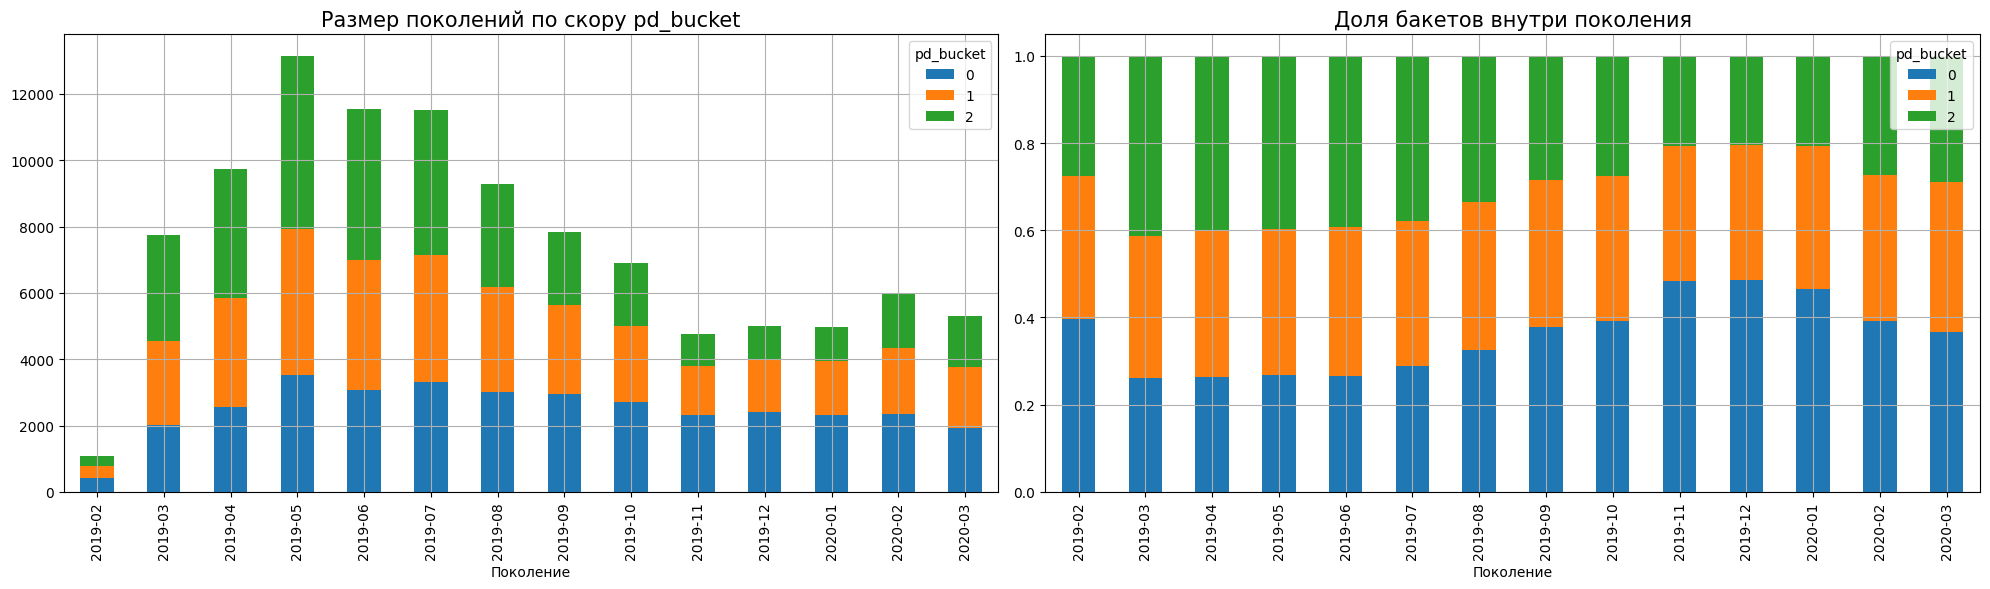

pd_bucket,0,1,2
2019-02,426,351,296
2019-03,2020,2530,3196
2019-04,2558,3288,3903
2019-05,3515,4421,5207
2019-06,3065,3940,4541
2019-07,3320,3832,4365
2019-08,3024,3152,3106
2019-09,2963,2658,2227
2019-10,2714,2295,1906
2019-11,2310,1471,991


In [7]:
def plot_distribution(data, bucket):
    first_mon = data[data["statement_num"] == 1]
    pivot_tab = pd.pivot_table(
        first_mon, index="gen_month_dt", columns=bucket, values="user_id",
        aggfunc="count", fill_value=0,
    )
    pivot_tab.index = [d.strftime("%Y-%m") for d in pivot_tab.index]

    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    pivot_tab.plot(kind="bar", stacked=True, ax=axes[0], grid=True)
    axes[0].set_title("Размер поколений по скору " + bucket, size=15)
    pivot_tab.div(pivot_tab.sum(axis=1), axis=0).plot(kind="bar", stacked=True, ax=axes[1], grid=True)
    axes[1].set_title("Доля бакетов внутри поколения", size=15)
    for ax in axes:
        ax.set_xlabel("Поколение")
    plt.tight_layout()
    plt.show()
    return pivot_tab


pivot_tab = plot_distribution(df, "pd_bucket")
pivot_tab

#### Вывод: 
Как мы видим по поколениям, февральское 2019 года содержит в себе 1073 клиента в общей сложности 3-х бакетов (426 + 351 + 296). В каждом примерно по 300-350 клиентов. А это сильно меньше других поколений. Остальные содержат примерно от 4700 до 13000 клиентов. Этот бакет февраля будет сильно менять данные, так как при маленьком объёме, если несколько клиентов уйдут в дефолт, точка кривой сразу сдвинется на 1/3 п.п. Из-за этого изменения винтаж превратится в шум, и содержательной кривой уже не получится. Поэтому поколение февраля 2019 года исключаю. А сами бакеты (0, 1, 2) целиком не исключаю, так как они полезны, наполнение в каждом из них достаточное по всему участку.

Ещё можно заметить, что сама структура выдач сильно менялась во времени. Если с марта по июль 2019 года на худший бакет, который зелёный (pd_bucket = 2) приходилось около 30-40 % выдач, то с ноября 2019 года по январь 2020 года доля бакета уменьшилась примерно до 20 %. Что интересно, при этом доля лучшего бакета, который синий (pd_bucket = 0) увеличилась с примерно 27 % до 50 %. Могу предположить, что скорее всего банк пересмотрел политику выдачи кредитов и ужесточил процедуру к концу 2019 года.

### Реализую исключение

In [8]:
df = df[df["gen_month_dt"] != "2019-02-01"]
print("Осталось всего поколений:", df["gen_month_dt"].nunique(), "А клиентов:", df["user_id"].nunique())

Осталось всего поколений: 13 А клиентов: 103747


### Кривые DEF Rate в разбивке по бакетам (0.5 баллов)

Реализуй функцию, которая отрисовывает винтажи DEF rate в разбивке по бакетам

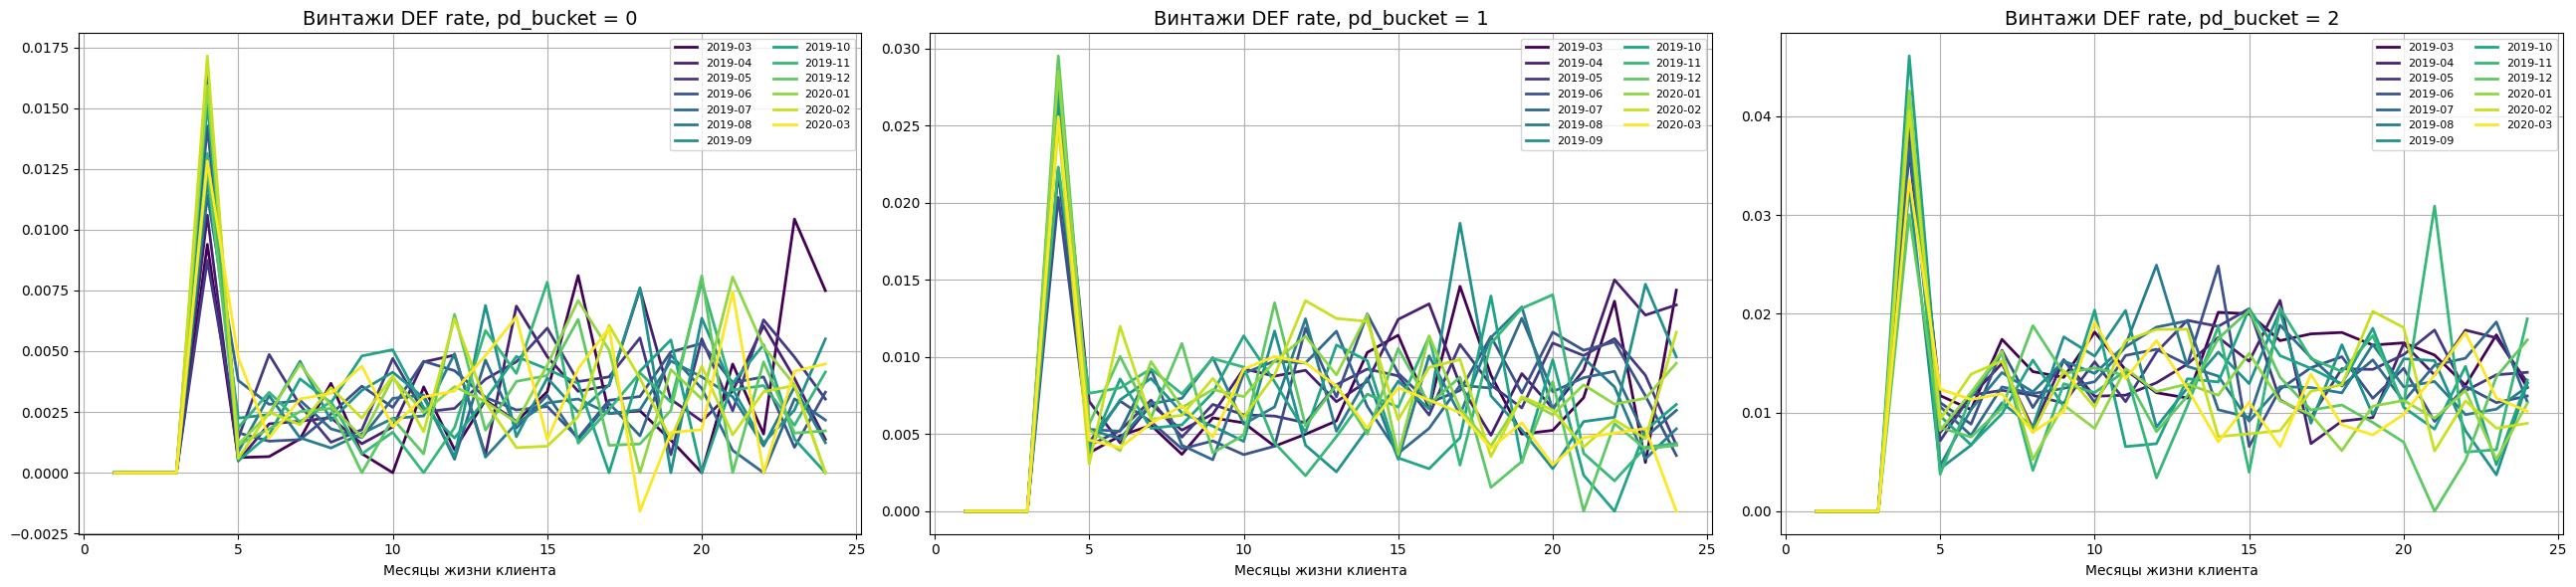

In [9]:
def plot_def_rate_by_generation(data, bucket, bucket_value, ax=None, title=""):
    vintage = def_rate_agg(data, [bucket, "gen_month_dt", "statement_num"])
    vintage["month_dt"] = (
        vintage["gen_month_dt"].values.astype("datetime64[M]")
        + (vintage["statement_num"].values - 1).astype("timedelta64[M]")
    )

    curves = (
        vintage[vintage[bucket] == bucket_value]
        .pivot(index="statement_num", columns="gen_month_dt", values="def_rate")
    )
    curves.columns = [c.strftime("%Y-%m") for c in curves.columns]

    ax = curves.plot(ax=ax, grid=True, lw=2, colormap="viridis")
    ax.set_title(title or f"Винтажи DEF rate, pd_bucket = {bucket_value}", size=14)
    ax.set_xlabel("Месяцы жизни клиента")
    ax.legend(fontsize=8, ncol=2)
    return curves


fig, axes = plt.subplots(1, 3, figsize=(26, 6))
for b in sorted(df["pd_bucket"].unique()):
    plot_def_rate_by_generation(df, "pd_bucket", b, ax=axes[int(b)])
plt.tight_layout()
plt.show()

#### Выводы: 
Как видно, форма кривой одинакова во всех 3 бакетах и даже во всех поколениях. Сначала идет 0 первые 3 месяца, а потом случается пик на 4-м месяце (так как по определению дефолта случается 1-ая просрочка). Далее виден провал в 5-м месяце, после плавный подъём, который достигает стабильного состояния, плато примерно к 12-15 месяцу. После видно, как уровень плато постепенно растёт по бакетам. А в 0-ом бакете он около 0.003-0.005, во 2-ом примерно 0.015-0.02. Это значит, что скор работает не только в начале, но и на всём пути жизни кредита. Внутри бакета винтажи лежат достаточно собранно по форме, в кучке, но при этом сильно скачут по уровню от точки к точке, особенно на последних месяцах. Такое происходит, потому что активных клиентов остаётся ещё меньше, за счет этого 1-2 наблюдения сильно двигают точку. Образуется шум, но это не настоящие различия между поколениями, поэтому усреднять их нужно с весами, а всю кривую лучше сгладить. Ещё заметно, что резкие скачки у разных поколений, например, сентябрь 2019 в 1-ом бакете или ноябрь 2019 во 2-ом бакете, приходятся не на один и тот же месяц жизни клиента, а скорее фокусируются в одном календарном периоде. Думаю, так можно отследить внешне экономическое воздействие.


### Особые точки (0.5 баллов) 
#### Есть ли в винтажах особые точки? Укажи их. Какова их природа? Нужно ли их исключать?

In [10]:
peaks = df[(df["statement_num"] == 4) & (df["def_flg"] == 1)]["user_id"].unique()
early = df[(df["statement_num"] == 1) & (df["user_id"].isin(peaks))]
print("Доля тех, у кого случилась просрочка в 1-ый же платёж:", round(early["dlq_flg"].mean(), 3))

for b in sorted(df["pd_bucket"].unique()):
    sub = df[df["pd_bucket"] == b]
    n4 = sub[(sub["statement_num"] == 4) & (sub["def_flg"] == 1)]["user_id"].nunique()
    n24 = sub[(sub["statement_num"] == 24) & (sub["def_flg"] == 1)]["user_id"].nunique()
    print(f"pd_bucket {int(b)}: Пик на 4-ый месяц даёт {n4 / n24:.1%} от всех дефолтов к 24-му месяцу")

vint_check = def_rate_agg(df, ["pd_bucket", "gen_month_dt", "statement_num"])
vint_check[vint_check["def_rate"] < 0][
    ["pd_bucket", "gen_month_dt", "statement_num", "new_def_cnt", "prev_act_cnt", "def_rate"]
]

Доля тех, у кого случилась просрочка в 1-ый же платёж: 0.99
pd_bucket 0: Пик на 4-ый месяц даёт 27.8% от всех дефолтов к 24-му месяцу
pd_bucket 1: Пик на 4-ый месяц даёт 21.1% от всех дефолтов к 24-му месяцу
pd_bucket 2: Пик на 4-ый месяц даёт 18.5% от всех дефолтов к 24-му месяцу


,pd_bucket,gen_month_dt,statement_num,new_def_cnt,prev_act_cnt,def_rate
305,0,2020-03-01,18,-1,631,-0.001585


#### Выводы: 
Как видно по таблице, нули на 1-3 месяцах не выброс, так как дефолт это просрочка начиная с 4-ого месяца. Соответственно, попасть в него раньше 4-го платежа физически невозможно. Главная особая точка и есть пик на 4-м месяце. Виден скачок в 4-8 раз относительно соседнего 5-го месяца во всех 3-х бакетах. Это подтверждается тем фактом, что 99 % клиентов, попавших в дефолт как раз на 4-м месяце, вышли в просрочку уже на самом 1-ом платеже. Это типичный дефолт на 1-ом платеже, т.е. фрод или заведомо неплатёжеспособные заёмщики. Исключать этот пик нельзя, так как он даёт от 18.5 % до 27.8 % всех дефолтов за все 2 года. И это реальные потери банка. Но и сгладить пик вместе с остальной кривой тоже нельзя, так как это разовое событие. Поэтому пик оставляю так, а всё сглаживание буду делать с 5-го месяца. Более того, нашлась 1 отрицательная точка, 0-ой бакет, это поколение марта 2020 года, 18-й месяц, (def_rate = -0.001585). Это можно проинтерпретировать как, какой-то клиент вышел из статуса дефолта, своего рода произошла реструктуризация. Это единственная такая точка на несколько сотен наблюдений. Не буду её трогать. Её вес во взвешенном среднем крайне мал, а полиномиальное сглаживание уберёт её совсем.

### Макроэкономические воздействие (2 балла)

#### Есть ли в винтажах DEF rate макроэкономическое воздействие (нарисуй график иллюстрирующее это воздействие)? Если да, то предположи какое событие его вызвало и почему?
#### В случае наличия внешнего влияния 
#### 1) Разложи кривые на внешнее воздействие и созревание кривых
#### 2) Отрисуй график внешнего воздествия
#### 3) Отрисуй вычищенные винтажи DEF rate в разбивке по бакетам
#### 4) Посчитай среднее для этих бакетов и реализуй сглаживание

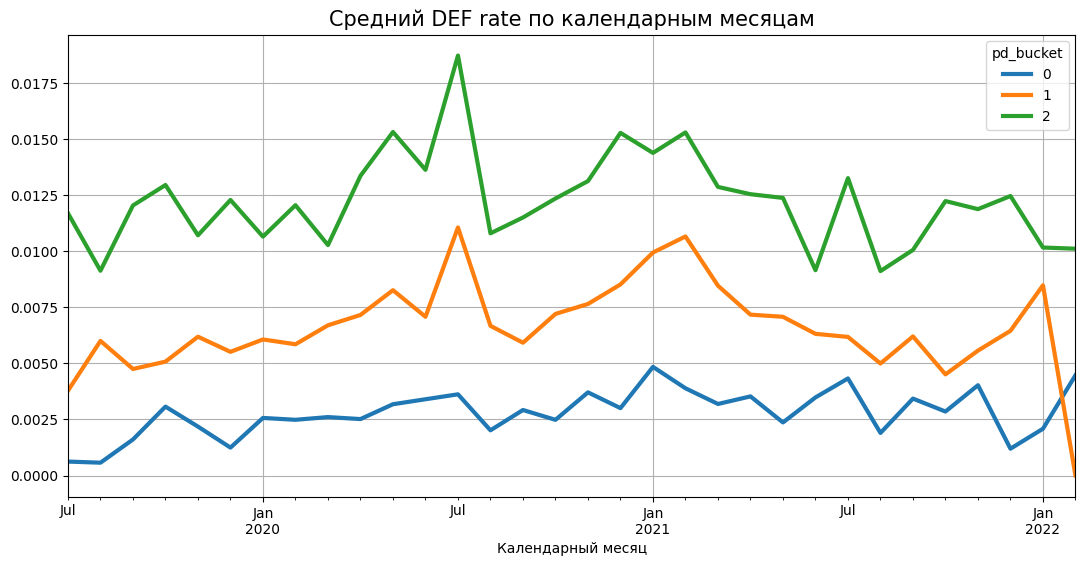

In [11]:
stable = 5

vint = def_rate_agg(df, ["pd_bucket", "gen_month_dt", "statement_num"])
vint["month_dt"] = (
    vint["gen_month_dt"].values.astype("datetime64[M]")
    + (vint["statement_num"].values - 1).astype("timedelta64[M]")
)

calendar = (
    vint[vint["statement_num"] >= stable]
    .pivot_table(index="month_dt", columns="pd_bucket", values="def_rate", aggfunc="mean")
)
calendar.plot(grid=True, lw=3, figsize=(13, 6))
plt.title("Средний DEF rate по календарным месяцам", size=15)
plt.xlabel("Календарный месяц")
plt.show()

Можно заметить, что по календарной шкале все 3 бакета ведут себя синхронно. С апреля 2020 DEF rate растёт, а в июле 2020 даёт общий пик во всех бакетах. Потом отражено событие это ковидный период конца марта 2020 года. Если дефолт это просрочка 4-ого и далее месяца, значит переставший платить в апреле клиент попадает в DEF только через 3-4 месяца, примерно в июле-августе. 2-ой скачок слабее выражен, в январе 2021 года, он объясняется окончанием кредитных каникул (по 106-ФЗ), а также новогодним провалом платёжной способности из-за трат на подарки и прочие бытовые праздничные расходы.

1) Здесь раскладываю кривые на внешнее воздействие и созревание кривых.

In [12]:
def curve_build(data, feature="def_rate", weight=None, n_iter=500, tol=1e-13):
    t_start = data["month_dt"].min()
    t_idx = ((data["month_dt"].dt.year * 12 + data["month_dt"].dt.month)
             - (t_start.year * 12 + t_start.month)).to_numpy()
    a_start = int(data["statement_num"].min())
    a_idx = data["statement_num"].to_numpy() - a_start
    y = data[feature].to_numpy(dtype=float)
    w = np.ones_like(y) if weight is None else data[weight].to_numpy(dtype=float)
    T, A = t_idx.max() + 1, a_idx.max() + 1
    E, M = np.ones(T), np.full(A, y.mean())
    for _ in range(n_iter):
        E = np.bincount(t_idx, w * y * M[a_idx], T) / np.maximum(np.bincount(t_idx, w * M[a_idx] ** 2, T), 1e-15)
        M_new = np.bincount(a_idx, w * y * E[t_idx], A) / np.maximum(np.bincount(a_idx, w * E[t_idx] ** 2, A), 1e-15)
        if np.max(np.abs(M_new - M)) < tol:
            M = M_new; break
        M = M_new
    scale = E.mean(); E, M = E / scale, M * scale
    pred = E[t_idx] * M[a_idx]
    r2 = 1 - np.sum(w * (y - pred) ** 2) / np.sum(w * (y - np.average(y, weights=w)) ** 2)
    external = pd.Series(E, index=pd.date_range(t_start, periods=T, freq="MS"), name="E")
    maturation = pd.Series(M, index=np.arange(a_start, a_start + A), name="M")
    return external, maturation, r2


def decomposition(data, group="pd_bucket", feature="def_rate", weight="prev_act_cnt",
                  stable_from=stable, min_generations=5):
    external_all, r2_all = {}, {}
    cleaned = data.copy()
    cleaned["E"] = 1.0
    for g in sorted(data[group].unique()):
        sub = data[(data[group] == g) & (data["statement_num"] >= stable_from)]
        n_gen = sub.groupby("month_dt")["gen_month_dt"].nunique()
        window = n_gen[n_gen >= min_generations].index
        E, M, r2 = curve_build(sub[sub["month_dt"].isin(window)], feature=feature, weight=weight)
        external_all[g], r2_all[g] = E, r2
        idx = cleaned[group] == g
        cleaned.loc[idx, "E"] = cleaned.loc[idx, "month_dt"].map(E).fillna(1.0).values
    cleaned[feature + "_clean"] = cleaned[feature] / cleaned["E"]
    return pd.DataFrame(external_all), pd.Series(r2_all, name="R2"), cleaned


external, r2, vint_clean = decomposition(vint)
print(r2.round(3))

0    0.239
1    0.408
2    0.556
Name: R2, dtype: float64


2) Теперь рисую график внешнего воздействия.

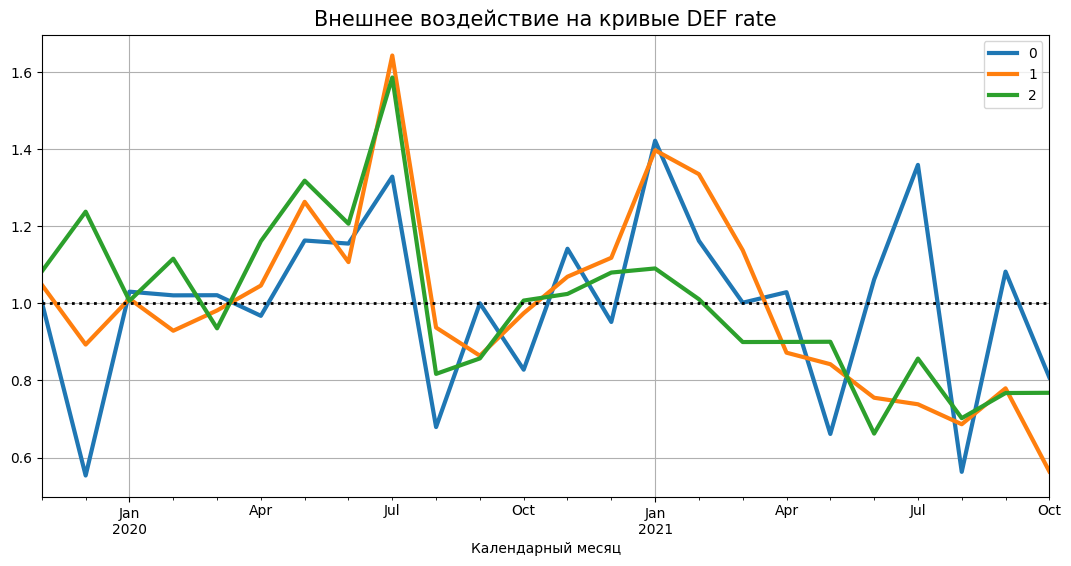

In [13]:
external.plot(grid=True, lw=3, figsize=(13, 6))
plt.axhline(1, color="black", ls=":", lw=2)
plt.title("Внешнее воздействие на кривые DEF rate", size=15)
plt.xlabel("Календарный месяц")
plt.show()

Разложение делаю методом переменных наименьших квадратов (МНК). Получается, при фиксированном созревании (M) оптимальное внешнее воздействие (E) считается явно, в один шаг, и наоборот, при фиксированном E точно так же находится M. Считаю с весами на число активных клиентов и оценкой внешнего воздействия только там, где есть минимум 5 поколений. Иначе на краях окна E считается только по 1-2 точкам и повторяет их шум. Все 3 кривые одновременно дают пик в июле 2020 года. Собственно это подтверждает наличие внешнего эффекта. Качество при разложении кривых на 2 компонента растёт с каждым бакетом от 0-ого, где R² = 0.24, в 1-ом = 0.41, и до 2-ого = 0.56. Делаю вывод, что чем реже событие, тем больше доля шума, который находится в точке.

3) Рисую вычищенные винтажи DEF rate в разбивке по бакетам.

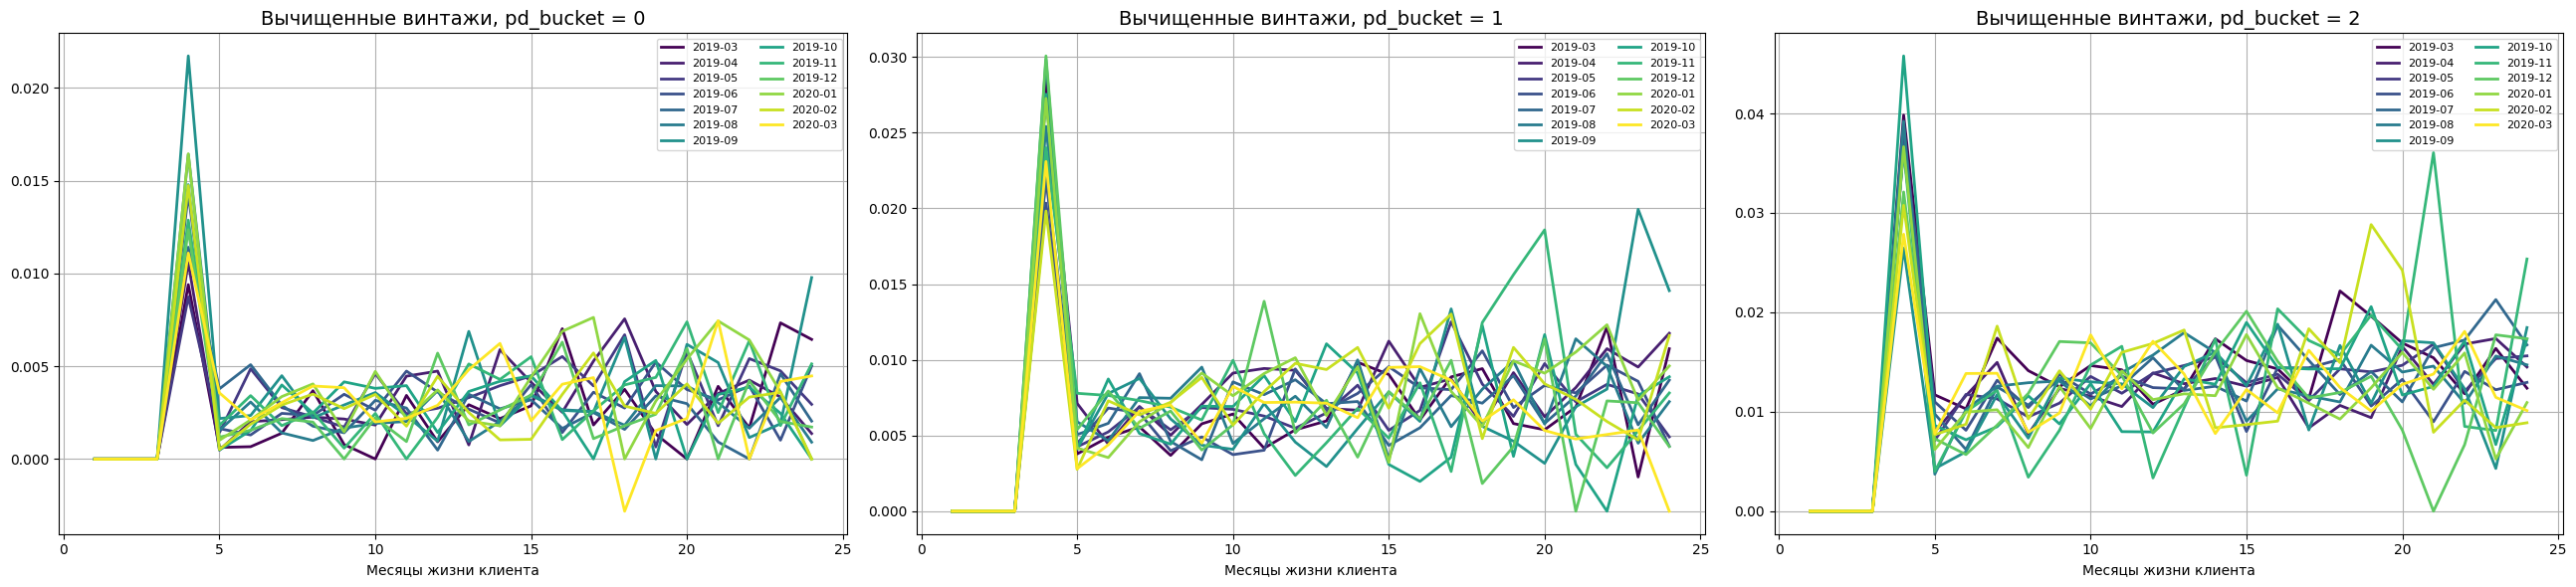

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(26, 6))
for b in sorted(vint_clean["pd_bucket"].unique()):
    curves = (vint_clean[vint_clean["pd_bucket"] == b]
              .pivot(index="statement_num", columns="gen_month_dt", values="def_rate_clean"))
    curves.columns = [c.strftime("%Y-%m") for c in curves.columns]
    ax = curves.plot(ax=axes[int(b)], grid=True, lw=2, colormap="viridis")
    ax.set_title(f"Вычищенные винтажи, pd_bucket = {int(b)}", size=14)
    ax.set_xlabel("Месяцы жизни клиента")
    ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

In [15]:
dispersion = []
for b in sorted(vint_clean["pd_bucket"].unique()):
    sub = vint_clean[(vint_clean["pd_bucket"] == b) & (vint_clean["statement_num"] >= stable)]
    before = (sub.groupby("statement_num")["def_rate"].std() / sub.groupby("statement_num")["def_rate"].mean()).mean()
    after = (sub.groupby("statement_num")["def_rate_clean"].std() / sub.groupby("statement_num")["def_rate_clean"].mean()).mean()
    dispersion.append({"pd_bucket": int(b), "Коэффициент вариации до вычищения": before, "после вычищения": after})

pd.DataFrame(dispersion).round(3)

,pd_bucket,Коэффициент вариации до вычищения,после вычищения
0,0,0.601,0.578
1,1,0.407,0.365
2,2,0.312,0.287


После вычищения ковидный период на винтажах уходит. Так, линии стали заметно более переплетенными между собой на 5-15 месяце. Коэффициент вариации между винтажами снизился во всех бакетах (С 0.601 до 0.578 в 0-ом бакете, с 0.407 до 0.365 в 1-ом бакете и с 0.312 до 0.287 во 2-ом бакете). Можно сказать, что эффект достаточно скромный, но в правильную сторону. В конце на графике виден шум редкого события, его макро-вычищение убрать не может, но с ним справится сглаживание.

### 4) Считаю среднее для этих бакетов и реализовываю сглаживание.

### Среднее по бакетам (0.5 баллов) 
Выбери один из способой нахождение средней кривой (возможные способы указаны в лекции). Обоснуй свой выбор.

Реализуй функцию построения среднего.

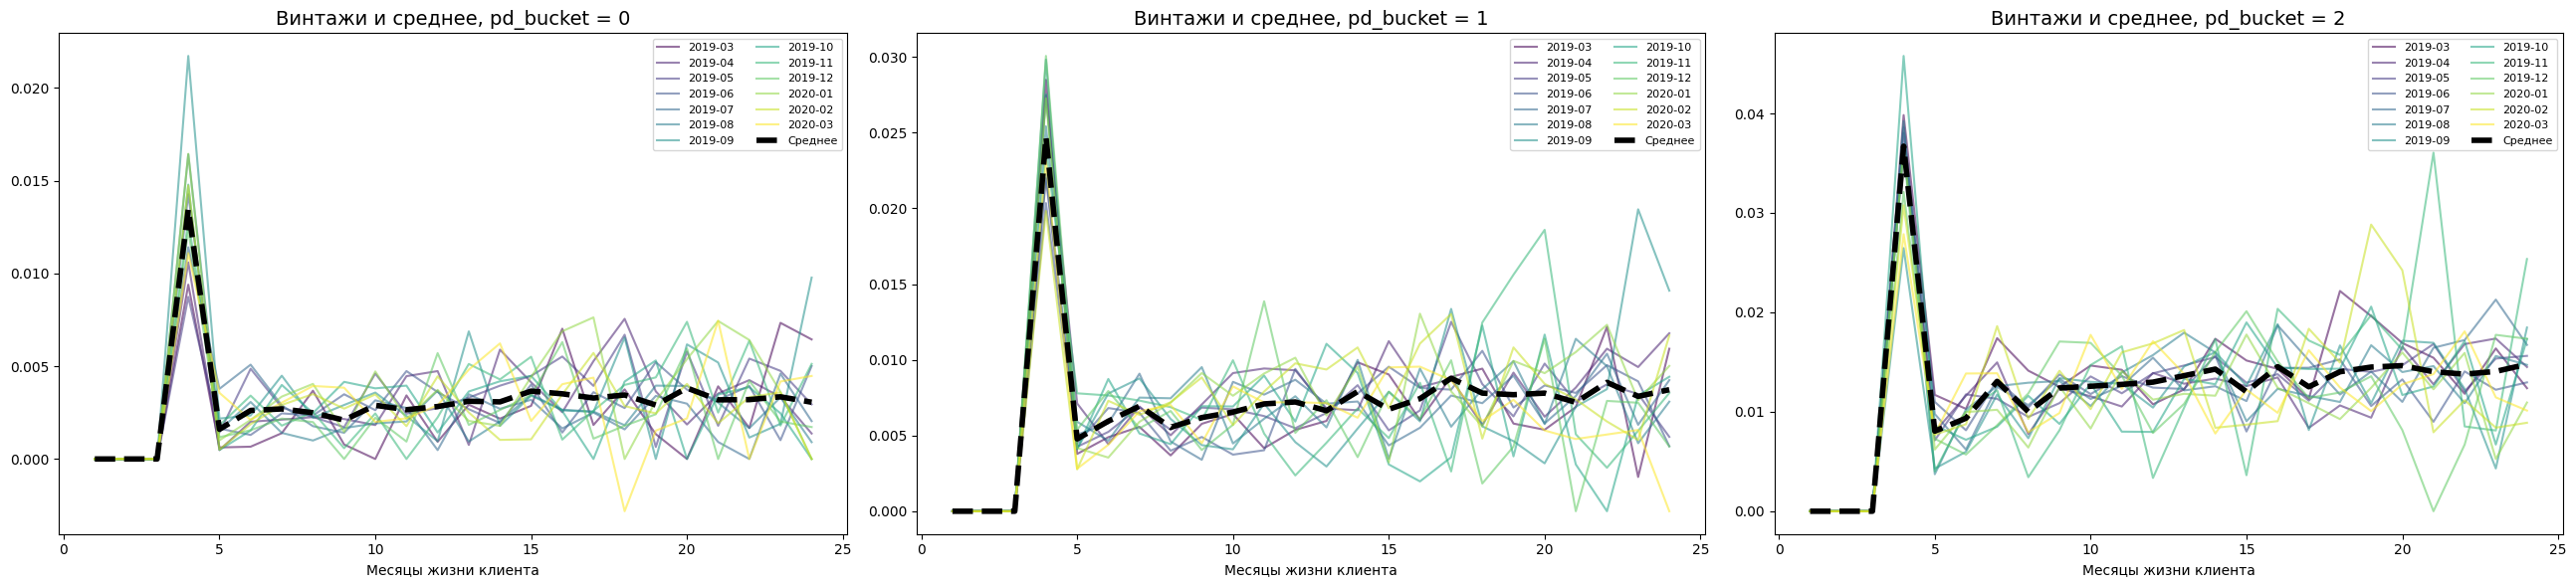

In [16]:
def calc_mean(data, value="def_rate_clean", weight="prev_act_cnt", group="pd_bucket", index="statement_num"):
    tmp = data.copy()
    tmp["_num"] = tmp[value] * tmp[weight]
    agg = tmp.groupby([group, index])[["_num", weight]].sum()
    return (agg["_num"] / agg[weight]).unstack(group)

mean_clean = calc_mean(vint_clean)


def plot_def_rate_mean(data, mean_curves, bucket_value, ax=None):
    curves = (data[data["pd_bucket"] == bucket_value]
              .pivot(index="statement_num", columns="gen_month_dt", values="def_rate_clean"))
    curves.columns = [c.strftime("%Y-%m") for c in curves.columns]
    ax = curves.plot(ax=ax, grid=True, lw=1.5, alpha=0.55, colormap="viridis")
    mean_curves[bucket_value].plot(ax=ax, lw=4, color="black", ls="--", label="Среднее")
    ax.set_title(f"Винтажи и среднее, pd_bucket = {int(bucket_value)}", size=14)
    ax.set_xlabel("Месяцы жизни клиента")
    ax.legend(fontsize=8, ncol=2)

fig, axes = plt.subplots(1, 3, figsize=(26, 6))
for b in sorted(vint_clean["pd_bucket"].unique()):
    plot_def_rate_mean(vint_clean, mean_clean, b, ax=axes[int(b)])
plt.tight_layout()
plt.show()

Здесь беру среднее по винтажам, взвешенное на число активных клиентов. Можно сказать, что это эквивалентно расчёту DEF rate на объединённой выборке всех поколений. Простое среднее в данном случае не подходит. У ранних поколений в начале тысячи клиентов, а у поздних к 24-му месяцу остаются только сотни, и без весов маленькое шумное поколение тянет кривую наравне с большим надёжным. После вычищения макроэкономического эффекта, систематического тренда между поколениями не осталось, а выброс половины данных только ухудшит оценку на шумной метрике.

### Сглаживание средних кривых (0.5 баллов) 

Рассмотри несколько функций для сглаживания кривой (можешь взять готовые из семинара, либо реализовать свои).

In [17]:
smooth_from, smooth_to = 5, 24

def approximation(curve, kind="polynom", degree=2, start=smooth_from, finish=smooth_to, alpha=0.25):
    result = curve.copy().astype(float)
    x = np.arange(start, finish + 1)
    y = curve.loc[start:finish].to_numpy(dtype=float)
    if kind in ("linear", "polynom"):
        deg = 1 if kind == "linear" else degree
        poly = np.poly1d(np.polyfit(x, y, deg))
        result.loc[start:finish] = poly(x)
        result.loc[finish + 1:] = poly(finish)
    elif kind == "ewma":
        smoothed = [y[0]]
        for v in y[1:]:
            smoothed.append(alpha * v + (1 - alpha) * smoothed[-1])
        result.loc[start:finish] = smoothed
        result.loc[finish + 1:] = smoothed[-1]
    return result

for b in sorted(mean_clean.columns):
    y = mean_clean[b].loc[smooth_from:smooth_to]
    print("pd_bucket", int(b))
    for name, kw in [("Линейная", dict(kind="linear")), ("Полином 2", dict(kind="polynom", degree=2)),
                     ("Полином 3", dict(kind="polynom", degree=3)), ("Ewma", dict(kind="ewma", alpha=0.25))]:
        fit = approximation(mean_clean[b], **kw).loc[smooth_from:smooth_to]
        r2 = 1 - ((y - fit) ** 2).sum() / ((y - y.mean()) ** 2).sum()
        print(f"  {name}: R²={r2:.3f}")

pd_bucket 0
  Линейная: R²=0.518
  Полином 2: R²=0.697
  Полином 3: R²=0.702
  Ewma: R²=0.462
pd_bucket 1
  Линейная: R²=0.628
  Полином 2: R²=0.709
  Полином 3: R²=0.710
  Ewma: R²=0.531
pd_bucket 2
  Линейная: R²=0.595
  Полином 2: R²=0.720
  Полином 3: R²=0.764
  Ewma: R²=0.481


#### Вывод: укажи выбранную функцию и обоснуй свой выбор. Были ли точки, к которым не применил(-a) сглаживание? Почему?

Я выбираю полином 2 степени. Он заметно точнее прямой, R² = 0.70 вместо 0.52-0.63, и почти не уступает полиному 3 степени, но устойчивее при продлении кривой за 24-й месяц. Экспоненциальное сглаживание проигрывает всем, поскольку оно повторяет шум исходной кривой с лагом вместо того, чтобы его убирать. Не применяю сглаживание к месяцам 1-4, так как 1-3 месяцы это структурные нули по определению статуса дефолта, а 4-й это по сути фродовый пик, разовое событие, которое больше не произойдёт, и оно исказило бы всю аппроксимацию.

### Отрисуй сглаженные кривые по всем трем бакетам PD

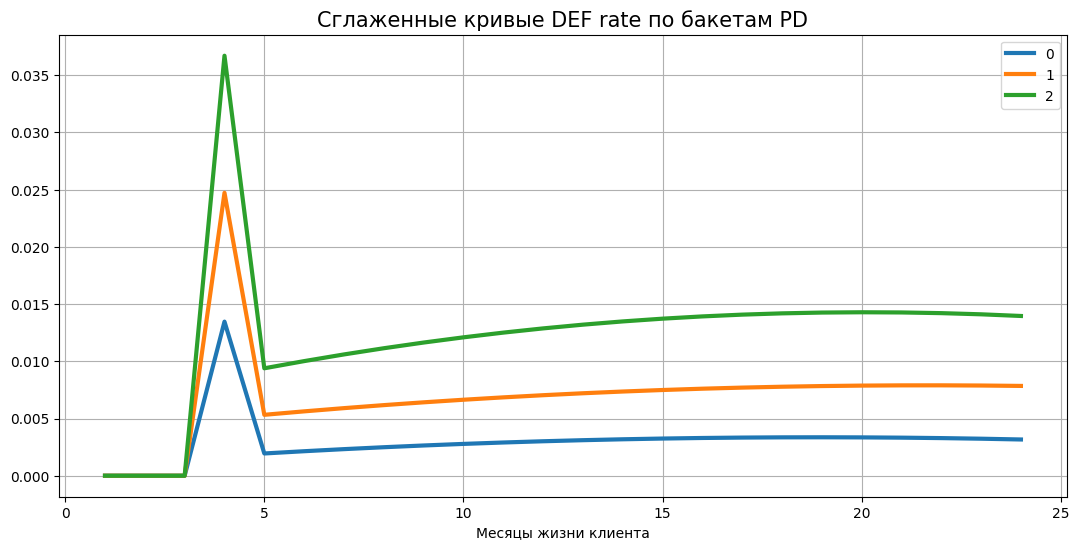

,0,1,2
statement_num,,,
1,0.0000,0.0000,0.0000
2,0.0000,0.0000,0.0000
3,0.0000,0.0000,0.0000
4,0.0135,0.0247,0.0367
5,0.0019,0.0053,0.0094
6,0.0021,0.0056,0.0100
7,0.0023,0.0059,0.0106
8,0.0025,0.0062,0.0111
9,0.0026,0.0064,0.0116


In [18]:
def_rate_curves = pd.DataFrame({
    int(b): approximation(mean_clean[b], kind="polynom", degree=2)
    for b in sorted(mean_clean.columns)
})

def_rate_curves.plot(grid=True, lw=3, figsize=(13, 6))
plt.title("Сглаженные кривые DEF rate по бакетам PD", size=15)
plt.xlabel("Месяцы жизни клиента")
plt.show()

def_rate_curves.to_csv("def_rate.csv")
def_rate_curves.round(4)

Не сглаживались 3 группы точек. Все они исключены прямо в параметрах функции (start = 5, finish = 24). Месяцы 1-3 остаются строгими нулями, потому что дефолт по определению не наступает раньше просрочки более 4 месяцев, как было определено ранее. А месяц 4-ый (фродовый пик) тоже не входит в окно сглаживания, если включить его в аппроксимацию, то полином исказит всю кривую. За 24-м месяцем данных нет, поэтому кривая продлевается константой на уровне последней сглаженной точки.

Ещё при разбитии кривых DEF Rate по бакетам, я заметила что-то похожее на макроэкономическое воздействие. И сейчас полностью выполнила все этапы, где видно точное наличие внешнего эффекта и до его вычищения в модели и сглаживания.

# Внедрение в NPV-модель

## Добавь в NPV-модель метод с расчетом DEF rate по твоей кривой

In [19]:
# Код NPV-модели с прошлого семинара

import numpy as np

BUCKET_PD = np.array([df[df["pd_bucket"] == b]["pd"].mean() for b in sorted(def_rate_curves.columns)])
CURVE_MATRIX = def_rate_curves.reindex(range(1, 25)).to_numpy()

class NPVModel:

    avg_missed_payments = 1.5
    recovery = 0.50
    dlq_penalty_amount = 500
    oper_costs = 100
    collection_costs = 600
    tax_rate = 0.20
    discounting_rate = 0.30
    eq_req = 0.125
    cost_of_funds = 0.16
    dlq_ratio = np.ones(101)*0.20
    dlq_ratio[0] = 0
    shift = 4
    clo_rate = 1 / (np.arange(shift, shift + 101) ** 2)
    acquisition_cost = 1000
    insurance_rate = 0.005
    cur_insur = 0.40
    dlq_insur = 0.60
    insurance_prob = 0.001

    def __init__(self):
        pass

    def model_balance_calculations(self, amount, rate, term):
        '''
        Расчет модельных баланса, выплаченных процентов, регулярного платежа
        :param amount: Сумма кредита
        :param rate: Ставка
        :param term: Срок
        :return:
        balance : np.array(101) : остаток тела долга по кредиту на каждый месяц
        interest : np.array(101) : выплата по процентам каждый месяц
        regular_payment : float : размер регулярного платежа
        '''

        regular_payment = round(amount * (rate / 12) *\
                                (1 + (rate / 12)) / (1 - ((1 + rate / 12) ** (-term))))
        # График баланса и процентов
        balance = np.zeros(101)
        interest = np.zeros(101)
        balance[0] = amount

        for i in range(1, term + 1):
            int_payment = balance[i - 1] * rate / 12
            debt_payment = regular_payment - int_payment
            balance[i] = max(0, round(balance[i - 1] - debt_payment))
            interest[i] = int_payment
        return balance, interest, regular_payment

    def distribution_calc(self, portfolio_distribution, pd=None, pa=None):
        '''
        Расчет распределения по статусам
        :param portfolio_distribution: график распределения по статусам
        :return:
        cur_dist : np.array(101) : доля клиентов в статусе CUR на каждый месяц
        dlq_dist : np.array(101) : доля клиентов в статусе DLQ на каждый месяц
        act_dist : np.array(101) : доля клиентов в статусе ACT на каждый месяц
        def_dist : np.array(101) : доля клиентов в статусе DEF на каждый месяц
        clo_dist : np.array(101) : доля клиентов в статусе CLO на каждый месяц
        '''
        
        cur_dist = portfolio_distribution['CUR']
        dlq_dist = portfolio_distribution['DLQ']
        act_dist = cur_dist + dlq_dist
        def_dist = portfolio_distribution['DEF'] 
        clo_dist = portfolio_distribution['CLO']


        return cur_dist, dlq_dist, act_dist, def_dist, clo_dist

    def cur_balance_calc(self, model_balance, cur_dist):
        '''
        Расчет модельного баланса в статусе CUR
        :param model_balance: плановый график баланса
        :param cur_dist: доля клиентов в статусе CUR на каждый месяц
        :return:
        principal_balance_cur : np.array(101) : principal balance в статусе CUR
        gross_balance_cur : np.array(101) : gross balance в статусе CUR
        '''
        principal_balance_cur = model_balance*cur_dist
        gross_balance_cur = model_balance*cur_dist
        return principal_balance_cur, gross_balance_cur

    def dlq_balance_calc(self, model_balance, regular_payment, dlq_dist):
        '''
        Расчет модельного баланса в статусе DLQ
        :param model_balance: плановый график баланса
        :param regular_payment: размер регулярного платежа
        :param dlq_dist: доля клиентов в статусе DLQ на каждый месяц
        :return:
        principal_balance_dlq : np.array(101) : principal balance в статусе DLQ
        gross_balance_dlq : np.array(101) : gross balance в статусе DLQ
        '''
        principal_balance_dlq = np.append(model_balance[1:], model_balance[-1])*dlq_dist
        gross_balance_dlq = (model_balance + regular_payment*self.avg_missed_payments)*dlq_dist
        return principal_balance_dlq, gross_balance_dlq

    def act_balance_calc(self, principal_balance_cur, principal_balance_dlq, gross_balance_cur, gross_balance_dlq):
        '''
        Расчет модельного баланса в статусе ACT
        :param principal_balance_cur: principal balance в статусе CUR
        :param principal_balance_dlq: principal balance в статусе DLQ
        :param gross_balance_cur: principal balance в статусе CUR
        :param gross_balance_dlq: principal balance в статусе DLQ
        :param dlq_dist: доля клиентов в статусе DLQ на каждый месяц
        :return:
        principal_balance_act : np.array(101) : principal balance в статусе ACT
        gross_balance_act : np.array(101) : gross balance в статусе ACT
        '''
        principal_balance_act = principal_balance_cur + principal_balance_dlq
        gross_balance_act = gross_balance_cur + gross_balance_dlq
        return principal_balance_act, gross_balance_act

    def def_balance_calc(self, model_balance, regular_payment, def_dist):
        '''
        Расчет модельного баланса в статусе DEF
        :param model_balance: плановый график баланса
        :param regular_payment: размер регулярного платежа
        :param def_dist: доля клиентов в статусе DEF на каждый месяц
        :return:
        principal_balance_def : np.array(101) : principal balance в статусе DEF
        gross_balance_def : np.array(101) : gross balance в статусе DEF
        '''
        principal_balance_def = np.zeros(101)
        gross_balance_def = np.zeros(101)

        def_dist_change = def_dist[4:] - def_dist[3:-1]
        principal_balance_def[4:] = np.cumsum(model_balance[:-4] * def_dist_change)
        gross_balance_def[4:] = np.cumsum((model_balance[4:] + 4 * regular_payment) * def_dist_change)

        return principal_balance_def, gross_balance_def

    def profit_calc(self, principal_balance_act, principal_balance_def, term, rate, dlq_dist):
        '''

        :param principal_balance_act: principal balance в статусе ACT
        :param principal_balance_def: principal balance в статусе DEF
        :param term: срок кредита
        :param rate: тавка по кредиту
        :param dlq_dist: доля клиентов в статусе DLQ на каждый месяц
        :return:
        profit : np.array(101) : доход на каждый месяц
        '''
        interest_profit = principal_balance_act*rate/12
        penatly_profit = dlq_dist*self.dlq_penalty_amount

        new_def_balance = np.append(principal_balance_def[1:], 0) - principal_balance_def
        recovery_profit = new_def_balance*self.recovery

        profit = interest_profit + recovery_profit + penatly_profit
        profit[term+1:] = 0

        return profit

    def loss_calc(self, gross_balance_act, principal_balance_def, term, act_dist, dlq_dist, def_dist):
        '''

        :param gross_balance_act: gross balance в статусе ACT
        :param principal_balance_def: principal balance в статусе DEF
        :param term: срок кредита
        :param act_dist: доля клиентов в статусе ACT на каждый месяц
        :param dlq_dist: доля клиентов в статусе DLQ на каждый месяц
        :param def_dist: доля клиентов в статусе DEF на каждый месяц
        :return:
        loss : np.array(101) : лосс на каждый месяц
        '''
        oper_loss = np.append(act_dist[1:], 0)*self.oper_costs
        loan_loss =  principal_balance_def - np.append(0, principal_balance_def[:-1])
        collection_loss = (np.append(dlq_dist[1:], 0) + np.append(def_dist[1:], 0))*self.collection_costs

        prev_gross_balance_act = np.append(gross_balance_act[0], gross_balance_act[1:])
        cost_of_funds_loss = prev_gross_balance_act*(1 - self.eq_req)*self.cost_of_funds/12

        loss = loan_loss + cost_of_funds_loss + oper_loss + collection_loss
        loss[term+1:] = 0

        return loss, loan_loss, cost_of_funds_loss, oper_loss, collection_loss

    def assets_liabilities_calc(self, gross_balance_act):
        '''

        :param gross_balance_act: gross balance в статусе ACT
        :return:
        assets : np.array(101) : активы в проекте
        eq_req_curve : np.array(101) : активы, обеспеченные капиталом
        fund_req_curve : np.array(101) : активы, обеспеченные фондами
        '''

        # assets
        assets = gross_balance_act

        #liabilities
        eq_req_curve = assets*self.eq_req
        fund_req_curve = assets*(1 - self.eq_req)

        return assets, eq_req_curve, fund_req_curve

    def niat_calc(self, profit, loss):
        '''
        Расчет NIAT
        :param profit: суммарный доход на каждый месяц
        :param loss: суммарный лосс на каждый месяц
        :return:
        nibt : np.array(101) : прибыль до налогообложения
        niat : np.array(101) : прибыль после налогообложения
        tax : np.array(101) : налог в каждом месяце
        '''

        nibt = profit - loss
        tax = nibt*self.tax_rate
        niat = nibt - tax

        return nibt, niat, tax

    def cashflow_calc(self, principal_balance_act, principal_balance_def, amount, profit,
                      cost_of_funds_loss, oper_costs, collection_costs, tax, niat, eq_req_curve, fund_req_curve):
        '''
        Расчет денежных потоков
        :param principal_balance_act: principal balance в статусе DEF
        :param principal_balance_def: principal balance в статусе DEF
        :param amount: срок кредита
        :param profit: доход на каждый месяц
        :param cost_of_funds_loss: лоссы на фондирование
        :param oper_costs: операционные расходы
        :param collection_costs: расходы на коллекшн
        :param tax: налог в каждом месяце
        :param niat: доход после налогообложения
        :param eq_req_curve: активы, обеспеченные капиталом
        :param fund_req_curve: активы, обеспеченные фондами
        :return:
        cf_to_client : np.array(101) : денежный поток к клиенту
        cf_to_shareholders : np.array(101) : денежный поток к акционерам
        cf_to_debtholders : np.array(101) : денежный поток к фондам
        cf_to_cost_and_tax : np.array(101) : денежный поток на косты и налоги
        '''
        # client
        delta_principal_balance_act = (np.append(0, principal_balance_act[:100]) - principal_balance_act)
        delta_principal_balance_def = (np.append(0, principal_balance_def[:100]) - principal_balance_def)
        repayments = delta_principal_balance_act - delta_principal_balance_def + profit
        cf_to_client = np.append(amount, -repayments[1:])

        # debtoholder
        fund_req_ch = fund_req_curve - np.append(fund_req_curve[0], fund_req_curve[:-1])
        fund_req_change = np.append(fund_req_curve[0], fund_req_ch[1:])
        cf_to_debtholders = cost_of_funds_loss - fund_req_change

        # shareholders
        eq_req_ch = eq_req_curve - np.append(eq_req_curve[0], eq_req_curve[:-1])
        cf_to_shareholders = niat - np.append(eq_req_curve[0], eq_req_ch[1:])

        # cost and tax
        cf_to_cost_and_tax = oper_costs + collection_costs + tax

        return cf_to_client, cf_to_shareholders, cf_to_debtholders, cf_to_cost_and_tax
        
    def insurance(self, amount, principal_balance_cur, principal_balance_dlq, cur_dist, dlq_dist):
        insured_client = cur_dist*self.cur_insur + dlq_dist*self.dlq_insur
        insurance_income = amount*self.insurance_rate*insured_client

        insured_balance = principal_balance_cur*self.cur_insur + principal_balance_dlq*self.dlq_insur
        insurance_pay = insured_balance*self.insurance_prob

        return insurance_income, insurance_pay


    def npv_calc(self, amount, rate, term, pd=None, with_insurance=True):
        '''
        Расчет NPV с внутренним вычислением portfolio_distribution
        :param amount: сумма кредита
        :param rate: ставка по кредиту
        :param term: срок кредита
        :param def_rate: доля дефолтных клиентов к концу срока
        :param clo_rate: доля закрытых клиентов к концу срока
        :param pd: вероятность дефолта к 12-ому месяцу
        :param pa: вероятность полного досрочного погашения к 6-ому месяцу
        :return: npv: чистая приведенная стоимость кредита
        '''

        # Считаем балансы
        model_balance, interest, regular_payment = self.model_balance_calculations(amount, rate, term)
        
        # Рассчитываем распределение по статусам
        cur_dist = np.zeros(101)
        dlq_dist = np.zeros(101)
        def_dist = np.zeros(101)
        clo_dist = np.zeros(101)
        act_dist = np.zeros(101)
        
        # В начале все клиенты в статусе CUR
        act_dist[0] = 1
        cur_dist[0] = 1
        
        self.def_rate = self.def_rate_calc(pd)
        
        for i in range(1, term + 1):
            clo_dist[i] = clo_dist[i - 1] + self.clo_rate[i] * act_dist[i - 1]
            def_dist[i] = def_dist[i - 1] + self.def_rate[i] * act_dist[i - 1]
            act_dist[i] = max(0, 1 - clo_dist[i] - def_dist[i])
            dlq_dist[i] = self.dlq_ratio[i] * act_dist[i]
            cur_dist[i] = act_dist[i] - dlq_dist[i]
            

        portfolio_distribution = {
            'CUR': cur_dist,
            'DLQ': dlq_dist,
            'DEF': def_dist,
            'CLO': clo_dist
        }

        # Считаем распределение
        cur_dist, dlq_dist, act_dist, def_dist, clo_dist = self.distribution_calc(portfolio_distribution)

        # Считаем балансы
        principal_balance_cur, gross_balance_cur = self.cur_balance_calc(model_balance, cur_dist)
        principal_balance_dlq, gross_balance_dlq = self.dlq_balance_calc(model_balance, regular_payment, dlq_dist)
        principal_balance_act, gross_balance_act = self.act_balance_calc(principal_balance_cur, principal_balance_dlq, gross_balance_cur, gross_balance_dlq)
        principal_balance_def, gross_balance_def = self.def_balance_calc(model_balance, regular_payment, def_dist)

        # Считаем профиты
        profit = self.profit_calc(principal_balance_act, principal_balance_def, term, rate, dlq_dist)
        loss, loan_loss, cost_of_funds_loss, oper_loss, collection_loss = self.loss_calc(gross_balance_act, principal_balance_def,
                                                                                        term, act_dist, dlq_dist, def_dist)
        if with_insurance:
            insurance_income, insurance_pay = self.insurance(amount, principal_balance_cur, principal_balance_dlq, cur_dist, dlq_dist)
            profit = profit + insurance_income
            profit[term+1:] = 0
            loss = loss + insurance_pay
            loss[term+1:] = 0

        nibt, niat, tax = self.niat_calc(profit, loss)

        # Считаем активы и денежные потоки
        assets, eq_req_curve, fund_req_curve = self.assets_liabilities_calc(gross_balance_act)
        cf_to_client, cf_to_shareholders, cf_to_debtholders, cf_to_cost_and_tax =\
            self.cashflow_calc(principal_balance_act, principal_balance_def, amount, profit, cost_of_funds_loss, oper_loss, collection_loss,
                            tax, niat, eq_req_curve, fund_req_curve)

        # Считаем NPV
        disc_curve = np.array([1 / ((1 + self.discounting_rate) ** (i / 12.)) for i in range(101)])
        pv = np.round(np.sum(disc_curve * cf_to_shareholders)).astype(int)
        npv = pv - self.acquisition_cost

        return npv
    
    
    def def_rate_calc(self, pd=None):
        if pd is None:
            pd = BUCKET_PD[1]
        rate = np.zeros(101)
        for a in range(1, 25):
            rate[a] = np.interp(pd, BUCKET_PD, CURVE_MATRIX[a - 1])
        rate[25:] = rate[24]
        return rate

Я подаю кривую не по 1 значению PD, а по 3 уже построенным кривым бакетами (через np.interp). Так, используя средний PD каждого бакета как опорную точку, потому что уровень кривых не равен самому PD напрямую. Ещё в 1-ом задании выяснилось, что фактический DEF rate примерно вдвое выше PD (2.35 %, а не 1.11 % на 12-м месяце и т.д.). Соответственно, брать PD как готовый уровень кривой было бы неправильно. После 24-го месяца кривая продолжается константой на уровне последней точки, так как данных дальше нет и там уже выходит плато.

Также я перенесла сюда страховку из прошлого ДЗ (отдельный метод insurance и флаг with_insurance в npv_calc), так как по условию задания страховка подключена. Параметры те же: премия 0.5 % от лимита, подключена у 40 % клиентов в CUR и 60 % в DLQ, страховой случай наступает с вероятностью 0.1 % и покрывает всю текущую задолженность.

## Посчитай NPV по кредиту с параметрами

- Срок кредита 2 года
- Годовая процентная ставка 21%
- Сумма кредита 1 млн
- Страховка подключена

In [20]:
mean_pd = df["pd"].mean()

model = NPVModel()
npv_no_insur = model.npv_calc(amount=1_000_000, rate=0.21, term=24, pd=mean_pd, with_insurance=False)
npv_insur = model.npv_calc(amount=1_000_000, rate=0.21, term=24, pd=mean_pd, with_insurance=True)

print("Средний PD портфеля:", round(mean_pd, 4))
print("NPV без страховки:", npv_no_insur)
print("NPV со страховкой:", npv_insur)
print("Дельта:", npv_insur - npv_no_insur)

Средний PD портфеля: 0.0375
NPV без страховки: -23004
NPV со страховкой: 1415
Дельта: 24419


Для клиента со средним по портфелю PD (примерно 3.7 %) NPV кредита на 2 года под 21 % и сумму 1 млн получился равным 1415 со страховкой и -23004 без неё. Разница огромная, около 24 419, и именно страховка переворачивает знак NPV с минуса на плюс. Причина та же, что я разбирала в прошлом ДЗ: банк собирает премию 0.5 % от лимита каждый месяц с большой доли клиентов, а платит возмещение крайне редко, всего в 0.1 % случаев, поэтому чистый эффект сильно положительный. Без страховки ставка 21 % при такой дефолтности и ставке дисконтирования 30 % просто не окупает риск и издержки на коллекшн и фондирование.

## Построй график зависимости NPV от скора, которым ты побил(-а) DEF rate

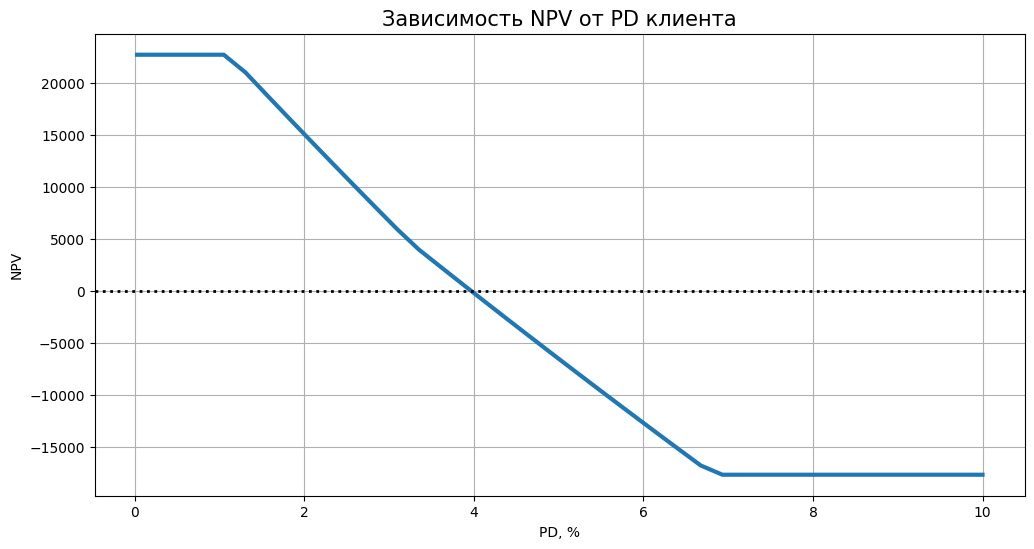

In [21]:
scores = np.linspace(df["pd"].min(), df["pd"].max(), 40)
npvs = [NPVModel().npv_calc(amount=1_000_000, rate=0.21, term=24, pd=s, with_insurance=True) for s in scores]

plt.figure(figsize=(12, 6))
plt.plot(scores * 100, npvs, lw=3)
plt.axhline(0, color="black", ls=":", lw=2)
plt.grid(True)
plt.title("Зависимость NPV от PD клиента", size=15)
plt.xlabel("PD, %")
plt.ylabel("NPV")
plt.show()

На графике видно, как NPV убывает с ростом PD. Чем рискованнее клиент, тем ближе кредит к убыточности, и это подтверждает адекватность встроенной кривой DEF rate. Кривая пересекает 0 примерно на PD около 4 %, то есть при ставке 21 % со страховкой кредит выгоден клиентам из лучшего бакета и части среднего, а худший бакет уже уходит в минус. Плоские участки на краях графика это следствие того, что кривая интерполируется между тремя опорными точками бакетов, и за пределами крайних значений PD она продолжается константой. Делаю вывод, что при таких параметрах банку нужно либо поднимать ставку для рискованных клиентов, либо ограничивать выдачи в верхнем бакете.

Спасибо большое за интересную домашку по NPV! Я чувствую себя маленьким банкиром) Хорошего дня! :)

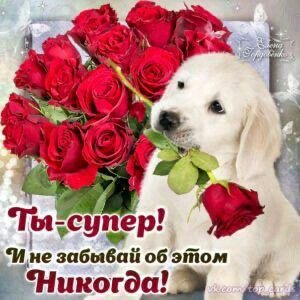